# **Validating Linear Regression Assumptions**

Linear regression assumes the following: Linearity, Independence, Normality, and Equal Variance (Homoscedasticity), which can be easily remembered using the acronym **LINE**

In this notebook, we’ll validate these assumptions as they were made when fitting a linear regression model to the mtcars dataset to predict fuel efficiency in miles per gallon.

In [ ]:
import pandas as pd

In [ ]:
# Load data as a data frame
cars = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/regression_sprint/mtcars.csv', index_col=0)
cars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
model,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


The mtcars dataset is a built-in R dataset featuring 32 observations (1973 - 74 car models) and 11 variables related to automobile design and performance.

**Key Data Details**

Observations: 32 (various car models)

Variables: 11

Origin: 1974 Motor Trend US Magazine

**Variables**

* mpg: Miles/(US) gallon
* cyl: Number of cylinders
* disp: Displacement in cubic inches
* hp: Gross horsepower
* drat: Driveshaft ratio
* wt: Weight in 1000s of lbs.
* qsec: Quarter mile time
* vs: Engine shape (0 = V-shaped, 1 = straight)
* am: Transmission (0 = automatic, 1 = manual)
* gear: Number of forward gears
* carb: Number of carburetors

In [ ]:
cars.shape
# With only 32 records, this is a small dataset

(32, 11)

In [ ]:
cars.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,32.0,20.090625,6.026948,10.400,15.42500,19.200,22.80,33.900
cyl,32.0,6.187500,1.785922,4.000,4.00000,6.000,8.00,8.000
disp,32.0,230.721875,123.938694,71.100,120.82500,196.300,326.00,472.000
hp,32.0,146.687500,68.562868,52.000,96.50000,123.000,180.00,335.000
drat,32.0,3.596563,0.534679,2.760,3.08000,3.695,3.92,4.930
wt,32.0,3.217250,0.978457,1.513,2.58125,3.325,3.61,5.424
qsec,32.0,17.848750,1.786943,14.500,16.89250,17.710,18.90,22.900
vs,32.0,0.437500,0.504016,0.000,0.00000,0.000,1.00,1.000
am,32.0,0.406250,0.498991,0.000,0.00000,0.000,1.00,1.000
gear,32.0,3.687500,0.737804,3.000,3.00000,4.000,4.00,5.000


**Note**
* There are no missing values
* All variables are represented numerically, but not all of them are on a numerical scale. (See vs and am)

In [ ]:
def get_proportions(df, col):
    """ Obtain counts and percentages for each category of a categorical variable.
    """
    count = df[col].value_counts()
    percent = df[col].value_counts()*100/df.shape[0]
    return pd.concat([count, percent], axis=1).set_axis(['count','percentage'], axis=1)

In [ ]:
get_proportions(cars, 'vs')

,count,percentage
vs,,
0,18,56.25
1,14,43.75


In [ ]:
get_proportions(cars, 'am')

,count,percentage
am,,
0,19,59.375
1,13,40.625


In [ ]:
# split predictors and outcome
X = cars.drop(['mpg'], axis=1)
y = cars['mpg']

**Linearity**

Assumption: the predictors have a linear relationship with the outcome.

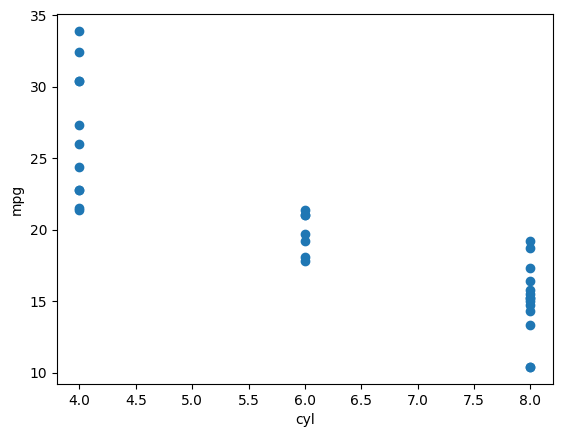

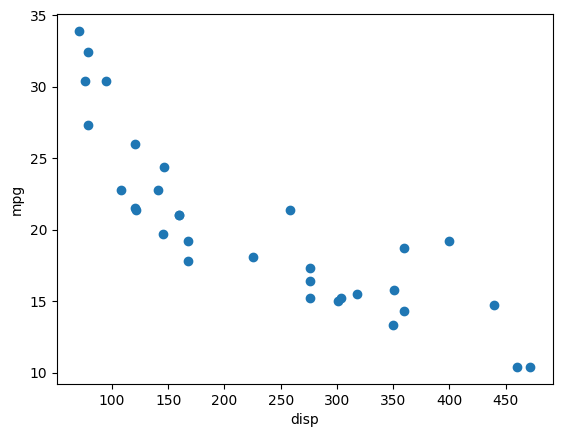

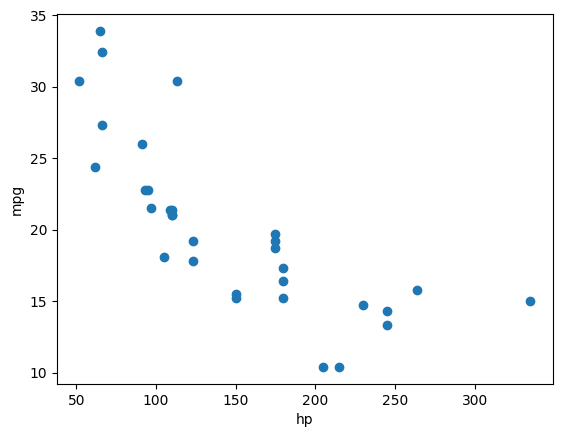

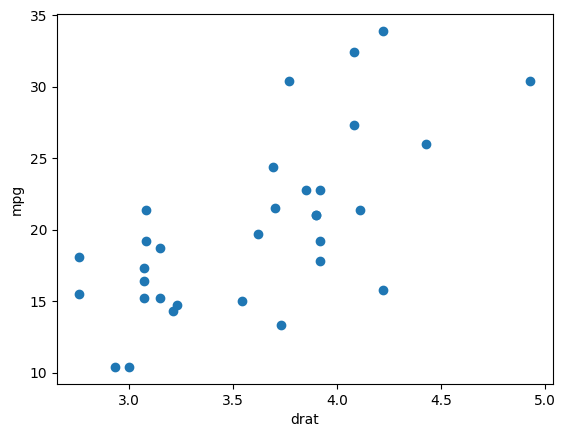

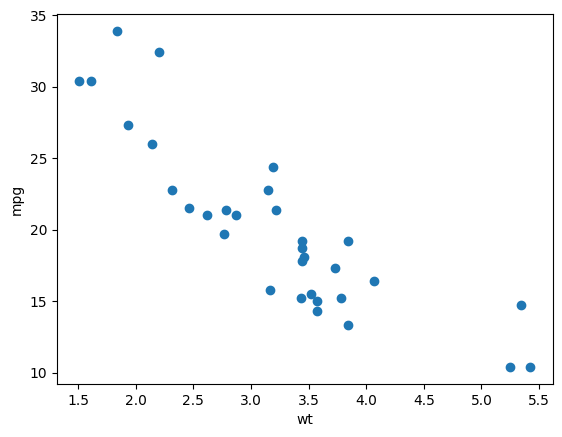

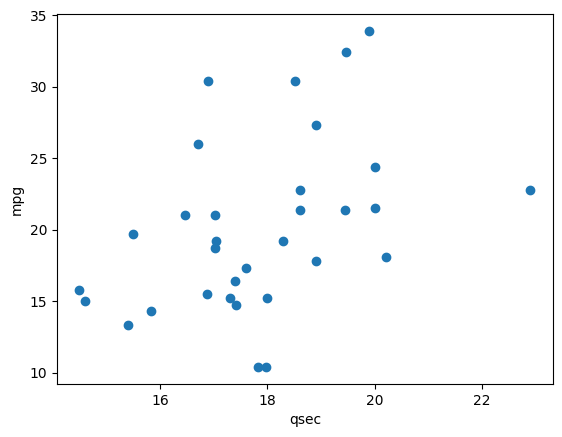

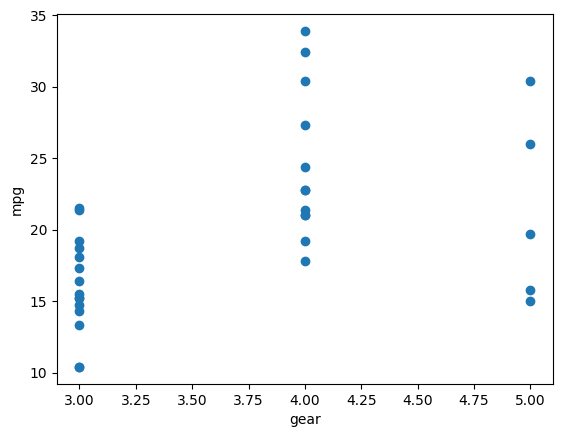

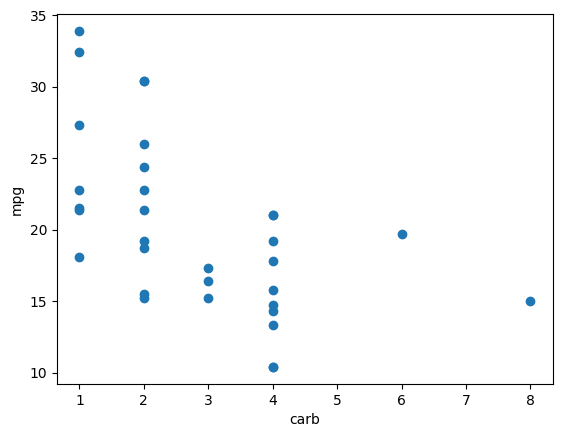

In [ ]:
# Check for a linear relationship between each numeric feature and the outcome using scatter diagrams

import matplotlib.pyplot as plt

numeric = ['cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'gear', 'carb']
for feature in numeric:
    plt.scatter(cars[feature], cars['mpg'])
    plt.xlabel(feature)
    plt.ylabel('mpg')
    plt.show()

In [ ]:
# Check for the strength and significance of linear relationship between each feature and the outcome using correlation coefficients

from scipy.stats import pearsonr

features = []
coefficients = []
p_values = []
for feature in numeric:
    correlation_coefficient, p_value = pearsonr(X[feature], y)
    correlation_coefficient = round(correlation_coefficient, 3)
    p_value = round(p_value, 3)
    features.append(feature)
    coefficients.append(correlation_coefficient)
    p_values.append(p_value)

In [ ]:
cor_df = pd.DataFrame({'Feature':features, 'Coefficient':coefficients, 'P-Value':p_values})
cor_df

,Feature,Coefficient,P-Value
0,cyl,-0.852,0.000
1,disp,-0.848,0.000
2,hp,-0.776,0.000
3,drat,0.681,0.000
4,wt,-0.868,0.000
5,qsec,0.419,0.017
6,gear,0.480,0.005
7,carb,-0.551,0.001


All coefficients are greater than 0.3 and significant. Therefore, the Linearity assumption has been fulfilled.

All other assumptions concern the residuals resulting from differences between model predictions and observed outcomes. So, we need to run a model first.

Since we are only validating assumptions and not evaluating model quality, we shall not split the data into training and testing sets. Additionally, this is a very small dataset, so splitting it would lead to an unacceptable risk of random error.

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
# create model object
cars_lm = LinearRegression()

In [ ]:
# train model
cars_lm.fit(X, y)

LinearRegression()

In [ ]:
y_pred = cars_lm.predict(X)

In [ ]:
residuals = y - y_pred

**Independence**

Assumption: residuals are independent of each other.

Text(0, 0.5, 'Residuals')

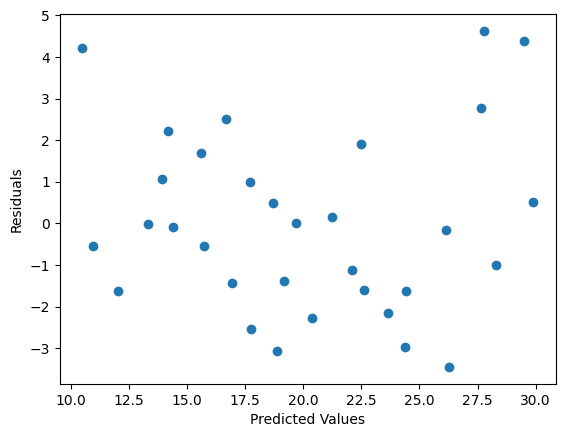

In [ ]:
plt.scatter(y_pred, residuals)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

If residuals are independent of each other, they should be randomly distributed above and below the X axis across all predicted values.

This seems to be the case in our data.

**The Durbin-Watson Test**

We can further validate the assumption of independence using the Durbin-Watson (DW) Test. This test tests the null hypothesis that there is no first-order autocorrelation among the residuals.

It can assume values from 0 to 4.

A value of 2 means that there is no first-order autocorrelation among the residuals.

Values less than 2 indicate positive first-order autocorrelation among the residuals.

Values more than 2 indicate negative first-order autocorrelation among the residuals.

At this point, understanding the meaning of “first-order autocorrelation” is not particularly important. Instead, remember that we want the test to have a value between 1.5 and 2.5 to say that the independence assumption has been fulfilled.

[Reference](https://help.sap.com/doc/saphelp_scm700_ehp02/7.0.2/en-US/e8/3cc95360267614e10000000a174cb4/content.htm?no_cache=true)

In [ ]:
from statsmodels.stats.stattools import durbin_watson

dw_statistic = durbin_watson(residuals)
print(f"Durbin-Watson Statistic: {dw_statistic:.3f}")

Durbin-Watson Statistic: 1.861


**Normality**

Assumption: residuals are normally distributed

Text(0, 0.5, 'Frequency')

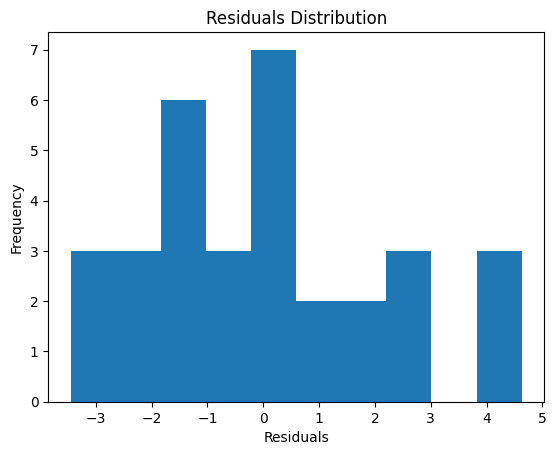

In [ ]:
plt.hist(residuals)
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

Based on the histogram, the residuals don’t seem to be normally distributed. However, a better way to validate this assumption is to use a statistical test.

We can test for the normality of residuals using statistical tests. Two main ones come to mind: the Shapiro-Wilk and Jarque-Bera tests.

When the dataset is small (<2000 observations), the Shapiro-Wilk test is prefered and so we’ll use it here.

**The Shapiro-Wilk test**

Null hypothesis: Data were drawn from a normal distribution.

[Reference](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html)

In [ ]:
from scipy.stats import shapiro

statistic, p_value = shapiro(residuals)

print(f"Shapiro-Wilk Test Statistic: {statistic}")
print(f"P-Value: {p_value}")

alpha = 0.05

if p_value > alpha:
    print("The data appear to be normally distributed (Fail to Reject H0).")
else:
    print("The data do not appear to be normally distributed (Reject H0).")

Shapiro-Wilk Test Statistic: 0.9569436305991051
P-Value: 0.22614893452392826
The data appear to be normally distributed (Fail to Reject H0).


**Equal variance (homoscedasticity)**

Assumption: residuals have a constant variance across all levels of the independent variable.

The assumption of homoscedasticity is checked visually by plotting the studentized residuals versus the predicted values or using a statistical test such as the Breusch-Pagan test.

To do this, we need to have a model built with statsmodels, not scipy, as done here. Therefore, we can settle for a rough estimate of the visual method by looking at the residuals-versus-predicted-values plot constructed earlier.

Since residuals are randomly distributed above and below the X axis across all predicted values, we can assume that the assumption holds.

Alternatively, we can rebuild the model using statsmodels to access more capabilities for validating assumptions.

In [ ]:
import statsmodels.formula.api as smf

In [ ]:
# Select features by constructing a formula string indicating the outcome and features to use in the model.
formula_str = cars.columns[0]+' ~ '+'+'.join(cars.columns[1:])
formula_str

'mpg ~ cyl+disp+hp+drat+wt+qsec+vs+am+gear+carb'

In [ ]:
# Create a model object using the formula string and the data to use.
cars_lm_2 = smf.ols(formula=formula_str, data=cars)

In [ ]:
# Fit model to data
cars_lm_2 = cars_lm_2.fit()

In [ ]:
# Show model output
print(cars_lm_2.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     13.93
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           3.79e-07
Time:                        12:14:22   Log-Likelihood:                -69.855
No. Observations:                  32   AIC:                             161.7
Df Residuals:                      21   BIC:                             177.8
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     12.3034     18.718      0.657      0.5

Right off the bat, we have the Durbin-Watson statistic in the model summary for the run with only the default settings.

The default settings also include a Jarque-Bera test for normality, but as discussed earlier, this is not ideal for datasets with <2000 observations. So, we’ll ignore that part of our results summary and conduct the Shapiro-Wilks test.

In [ ]:
residuals_2 = cars_lm_2.resid

In [ ]:
from scipy.stats import shapiro

In [ ]:
shapiro(residuals_2)

ShapiroResult(statistic=np.float64(0.9569436305991027), pvalue=np.float64(0.22614893452389334))

In [ ]:
# Checking for homoscedasticity visually
# Get the studentised residuals

st_residuals_df = cars_lm_2.outlier_test() # returns a DataFrame with the first column containing the studentised residuals
st_residuals_df.head()

,student_resid,unadj_p,bonf(p)
Mazda RX4,-0.714186,0.483365,1.0
Mazda RX4 Wag,-0.488884,0.630242,1.0
Datsun 710,-1.540379,0.139141,1.0
Hornet 4 Drive,0.068140,0.946351,1.0
Hornet Sportabout,0.416067,0.681792,1.0


In [ ]:
st_residuals = st_residuals_df['student_resid']

In [ ]:
y_pred_2 = cars_lm_2.predict(X)

Text(0, 0.5, 'Studentized Residuals')

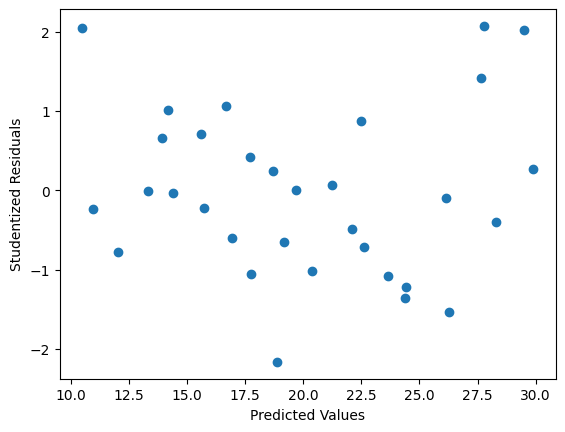

In [ ]:
plt.scatter(y_pred_2, st_residuals)
plt.xlabel('Predicted Values')
plt.ylabel('Studentized Residuals')

Since studentised residuals are randomly distributed above and below the X axis across all predicted values, the assumption holds.

In [ ]:
# Checking for homoscedasticity using the Breusch-Pagan test

# To run the Breusch-Pagan test, you need predictors that include a constant.
import statsmodels.api as sm

In [ ]:
X_with_intercept = sm.add_constant(X)

In [ ]:
cars_lm_3 = sm.OLS(y, X_with_intercept).fit()

In [ ]:
residuals_3 = cars_lm_3.resid

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan

In [ ]:
lm_statistic, lm_p_value, f_statistic, f_p_value = het_breuschpagan(residuals_3, X_with_intercept)

print(f"Lagrange Multiplier (LM) statistic: {lm_statistic:.4f}")
print(f"LM p-value: {lm_p_value:.3f}")
print(f"F-statistic: {f_statistic:.3f}")
print(f"F p-value: {f_p_value:.3f}")

alpha = 0.05
if lm_p_value < alpha:
    print("Result: Reject the null hypothesis (H0). Heteroscedasticity is present.")
else:
    print("Result: Fail to reject the null hypothesis (H0). Homoscedasticity is present.")

Lagrange Multiplier (LM) statistic: 14.9136
LM p-value: 0.135
F-statistic: 1.833
F p-value: 0.116
Result: Fail to reject the null hypothesis (H0). Homoscedasticity is present.
